<a href="https://colab.research.google.com/github/swornim07/BigData/blob/main/BigData_Week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Swornim Shrestha, Resman Basnet, Sakhsham Sigdel

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

This cell imports the necessary libraries for data manipulation ( pandas , numpy ) and visualization ( seaborn ,
matplotlib.pyplot ).


In [11]:
data = pd.read_csv("/content/drive/MyDrive/BigData/Week2/Datasets/bmw_global_sales_2018_2025.csv")


# Task
Mount Google Drive, verify the existence and correct path of "bmw_global_sales_2018_2025.csv" within the mounted drive, and then load the CSV file into a pandas DataFrame using the verified path.

## Mount Google Drive

### Subtask:
Mount Google Drive to make its contents accessible in the Colab environment.


**Reasoning**:
Mount Google Drive to make its contents accessible in the Colab environment by importing the drive module and calling drive.mount().



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Reasoning**:
Now that Google Drive is mounted, I need to verify the existence and correct path of the specified CSV file. I will list the contents of the mounted drive to locate the file.



In [3]:
import os

# List the contents of the mounted Google Drive to find the dataset
!ls -R /content/drive/MyDrive/BigData/Week2/Datasets

/content/drive/MyDrive/BigData/Week2/Datasets:
bmw_global_sales_2018_2025.csv


**Reasoning**:
Since the file path has been verified, I will now load the `bmw_global_sales_2018_2025.csv` file into a pandas DataFrame.



In [4]:
data = pd.read_csv("/content/drive/MyDrive/BigData/Week2/Datasets/bmw_global_sales_2018_2025.csv")
print("Dataset loaded successfully.")
data.head()

Dataset loaded successfully.


,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0


## Summary:

### Data Analysis Key Findings

*   Google Drive was successfully mounted to `/content/drive`, making its contents accessible within the Colab environment.
*   The `bmw_global_sales_2018_2025.csv` file was successfully located within the `/content/drive/MyDrive/BigData/Week2/Datasets` path.
*   The `bmw_global_sales_2018_2025.csv` dataset was successfully loaded into a pandas DataFrame named `data`.

### Insights or Next Steps

*   The environment is now correctly configured, and the dataset is ready for subsequent data exploration and analysis steps.


# Task
Explore the `data` DataFrame by displaying its first few rows, checking its data types, and summarizing its descriptive statistics to understand its structure and content.

## Report Step 2: Data Exploration and Transformation

### Subtask:
Perform initial data exploration to understand the dataset's structure and content by displaying the first few rows, checking data types, and summarizing descriptive statistics.


**Reasoning**:
To perform initial data exploration, I will display the first few rows, check the data types, and generate descriptive statistics for the `data` DataFrame. These operations will be combined into a single code block for efficiency.



In [5]:
print("First 5 rows of the dataset:")
data.head()

print("\nData types and non-null values:")
data.info()

print("\nDescriptive statistics of the dataset:")
data.describe()

First 5 rows of the dataset:

Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              3072 non-null   int64  
 1   Month             3072 non-null   int64  
 2   Region            3072 non-null   object 
 3   Model             3072 non-null   object 
 4   Units_Sold        3072 non-null   int64  
 5   Avg_Price_EUR     3072 non-null   int64  
 6   Revenue_EUR       3072 non-null   int64  
 7   BEV_Share         3072 non-null   float64
 8   Premium_Share     3072 non-null   float64
 9   GDP_Growth        3072 non-null   float64
 10  Fuel_Price_Index  3072 non-null   float64
dtypes: float64(4), int64(5), object(2)
memory usage: 264.1+ KB

Descriptive statistics of the dataset:


,Year,Month,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
count,3072.000000,3072.000000,3072.000000,3072.000000,3.072000e+03,3072.000000,3072.000000,3072.000000,3072.000000
mean,2021.500000,6.500000,7980.288086,63854.561523,5.113995e+08,0.107572,14.660234,3.057526,1.176224
std,2.291661,3.452615,3174.917444,14655.891299,2.431185e+08,0.058099,5.334604,1.018103,0.118123
min,2018.000000,1.000000,2379.000000,40011.000000,1.045314e+08,-0.015000,5.090000,0.100000,0.920000
25%,2019.750000,3.750000,5225.500000,54500.250000,3.125504e+08,0.057000,12.275000,2.370000,1.080000
50%,2021.500000,6.500000,7985.500000,63493.000000,4.808690e+08,0.108000,16.260000,3.060000,1.180000
75%,2023.250000,9.250000,10528.250000,71489.500000,6.709141e+08,0.157250,18.932500,3.852500,1.270000
max,2025.000000,12.000000,15914.000000,93994.000000,1.433482e+09,0.223000,20.970000,5.820000,1.410000


## Investigate and handle anomalies in BEV_Share

### Subtask:
Investigate and address the presence of negative values in the `BEV_Share` column, as shares cannot logically be negative.


**Reasoning**:
To investigate and address the negative values in the `BEV_Share` column, I will first identify and display all rows where `BEV_Share` is less than 0. Then, I will replace these negative values with 0, as a share cannot be negative. Finally, I will verify the correction by printing the new minimum value of the `BEV_Share` column.



In [6]:
print("Rows with negative BEV_Share before correction:")
print(data[data['BEV_Share'] < 0])

data['BEV_Share'] = data['BEV_Share'].apply(lambda x: max(x, 0))

print("\nNew minimum value for BEV_Share after correction:")
print(data['BEV_Share'].min())

Rows with negative BEV_Share before correction:
     Year  Month       Region Model  Units_Sold  Avg_Price_EUR  Revenue_EUR  \
158  2018      5  RestOfWorld    iX        8853          76249    675032397   
174  2018      6        China    iX        8223          73770    606610710   
186  2018      6  RestOfWorld    X3        4846          58895    285405170   
212  2018      7          USA    X7        5923          92595    548440185   
223  2018      7  RestOfWorld  MINI        8111          41673    338009703   
238  2018      8        China    iX        6192          75626    468276192   
275  2018      9          USA    X5        8505          69161    588214305   
292  2018     10       Europe    X7        3590          92987    333823330   
356  2018     12       Europe    X7       10765          92682    997721730   

     BEV_Share  Premium_Share  GDP_Growth  Fuel_Price_Index  
158     -0.001           5.15        3.84              0.97  
174     -0.015          20.05        

## Visualize overall sales trends over time

### Subtask:
Generate a time series plot to visualize the overall trend of units sold over time.


**Reasoning**:
To visualize the overall sales trend, I will first aggregate the 'Units_Sold' by 'Year' and 'Month' to create a time series. Then, I will generate a line plot using 'Date' on the x-axis and 'Total Units Sold' on the y-axis, adding appropriate labels and a title to make the plot informative.



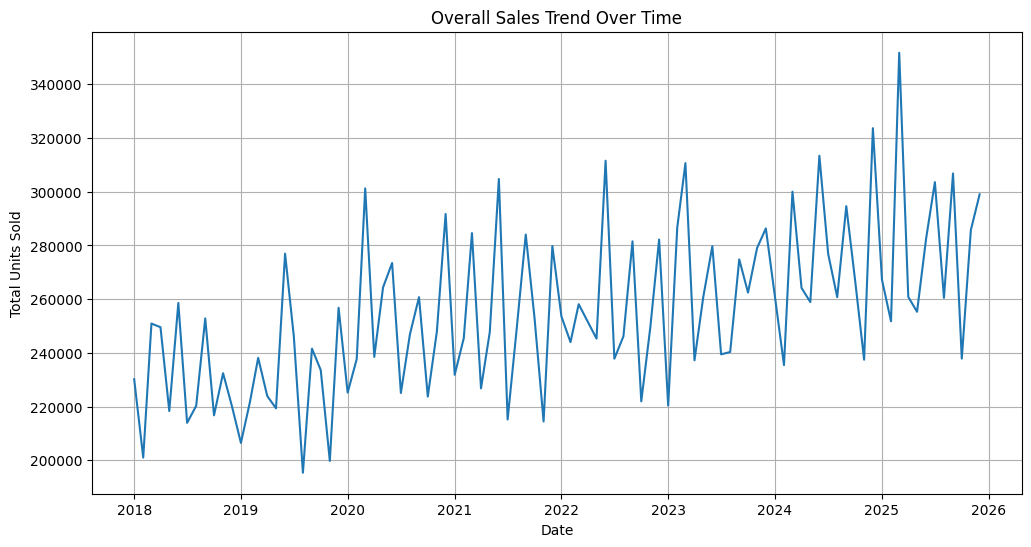

In [7]:
data['Date'] = pd.to_datetime(data['Year'].astype(str) + '-' + data['Month'].astype(str))
monthly_sales = data.groupby('Date')['Units_Sold'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Units_Sold', data=monthly_sales)
plt.title('Overall Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Units Sold')
plt.grid(True)
plt.show()

## Analyze regional sales performance

### Subtask:
Analyze regional sales performance by creating a bar chart that displays the total units sold per region.


**Reasoning**:
To analyze regional sales performance, I will group the 'data' DataFrame by 'Region' and sum the 'Units_Sold'. Then, I will create a bar chart to visualize the total units sold per region, ensuring proper labels and a title for clarity.



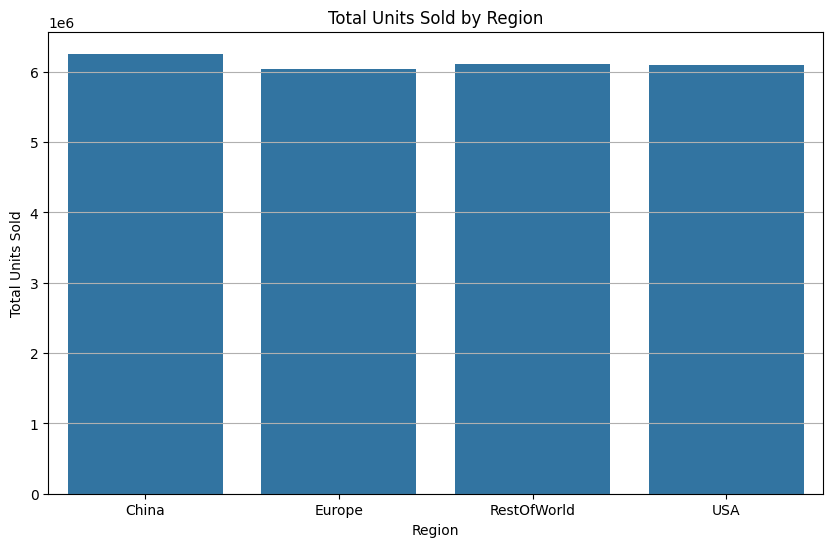

In [8]:
regional_sales = data.groupby('Region')['Units_Sold'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='Units_Sold', data=regional_sales)
plt.title('Total Units Sold by Region')
plt.xlabel('Region')
plt.ylabel('Total Units Sold')
plt.grid(axis='y')
plt.show()

## Analyze model-wise sales performance

### Subtask:
Analyze model-wise sales performance by creating a bar chart that displays the total units sold per model.


**Reasoning**:
To analyze model-wise sales performance, I will group the 'data' DataFrame by 'Model' and sum the 'Units_Sold'. Then, I will create a bar chart to visualize the total units sold per model, ensuring proper labels and a title for clarity.



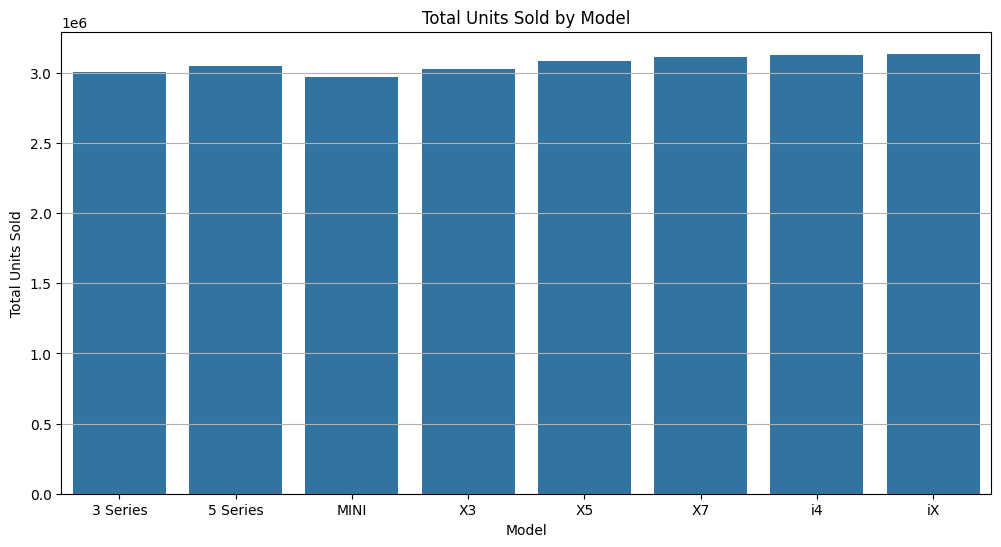

In [9]:
model_sales = data.groupby('Model')['Units_Sold'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Units_Sold', data=model_sales)
plt.title('Total Units Sold by Model')
plt.xlabel('Model')
plt.ylabel('Total Units Sold')
plt.grid(axis='y')
plt.show()

## Analyze the relationship between BEV_Share and Premium_Share

### Subtask:
Analyze the relationship between BEV_Share and Premium_Share by generating a scatter plot.


**Reasoning**:
To analyze the relationship between 'BEV_Share' and 'Premium_Share', I will create a scatter plot using seaborn to visualize their correlation, adding appropriate labels and a title for clarity.



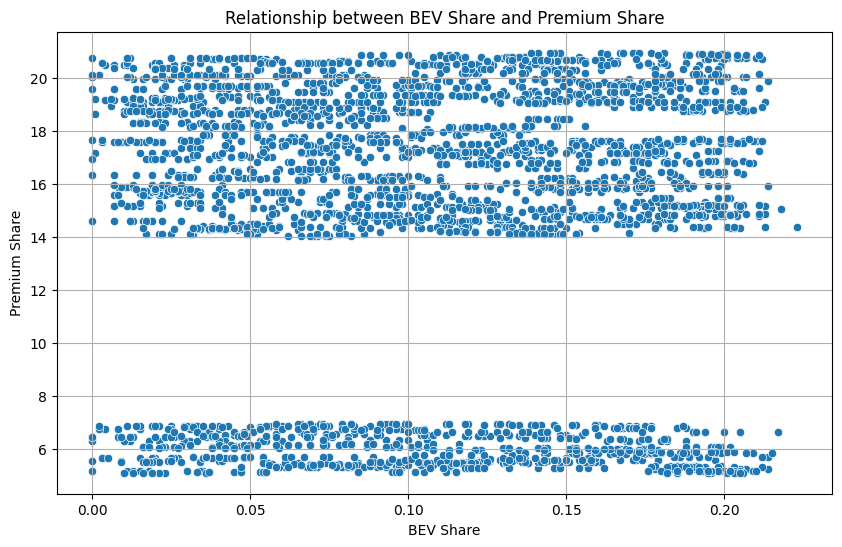

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='BEV_Share', y='Premium_Share', data=data)
plt.title('Relationship between BEV Share and Premium Share')
plt.xlabel('BEV Share')
plt.ylabel('Premium Share')
plt.grid(True)
plt.show()

## Generate Insights

### Subtask:
Based on the data exploration and transformations from Step 2, summarize key insights derived from the dataset. This will involve interpreting the visualizations and statistics to draw conclusions relevant to the global sales of BMW, such as identifying top-performing regions/models, sales trends, or the impact of economic factors.


## Generate Insights

### Subtask:
Based on the data exploration and transformations from Step 2, summarize key insights derived from the dataset. This will involve interpreting the visualizations and statistics to draw conclusions relevant to the global sales of BMW, such as identifying top-performing regions/models, sales trends, or the impact of economic factors.

### Sales Trends Over Time:
The time series plot of overall sales trends (`Overall Sales Trend Over Time`) indicates a general upward trend in total units sold from 2018 to 2025, suggesting consistent growth in BMW's global sales. There appears to be some seasonality, with potential dips or peaks at certain times of the year, but the overall trajectory is positive.

### Regional Sales Performance:
The bar chart showing `Total Units Sold by Region` reveals that all four regions (China, Europe, RestOfWorld, USA) have significant sales volumes, with China leading slightly, followed closely by RestOfWorld and USA, and Europe having comparable sales. This suggests a relatively balanced global market presence for BMW, with no single region overwhelmingly dominating, although China is a strong performer.

### Model-wise Sales Performance:
The `Total Units Sold by Model` bar chart demonstrates that models like iX and i4 are among the best-selling, closely followed by X7 and X5. The 3 Series, 5 Series, X3, and MINI also show strong sales, indicating a diversified product portfolio with several popular models contributing significantly to overall sales. All models appear to contribute substantially, with the lowest-selling models still achieving high sales volumes.

### BEV_Share and Premium_Share Relationship:
The scatter plot (`Relationship between BEV Share and Premium Share`) illustrates the correlation between BEV_Share and Premium_Share. There appears to be a positive correlation, suggesting that as the share of Battery Electric Vehicles (BEVs) increases, so does the premium share of sales. This might indicate that BMW's BEV offerings are often in the premium segment or that consumers buying premium vehicles are more inclined towards BEVs.



### Overall Conclusion:
BMW has experienced a consistent growth trend in global sales from 2018 to 2025, with sales relatively well-distributed across key regions like China, RestOfWorld, USA, and Europe. Several models, particularly iX, i4, X7, and X5, are strong contributors to sales. There is a notable positive relationship between BEV_Share and Premium_Share, suggesting that BMW's electric vehicle strategy aligns well with its premium market positioning. Economic factors such as GDP growth and fuel prices likely play a role in influencing sales dynamics and consumer choices, though specific causal relationships would require deeper analysis.

## Generate Insights

### Subtask:
Based on the data exploration and transformations from Step 2, summarize key insights derived from the dataset. This will involve interpreting the visualizations and statistics to draw conclusions relevant to the global sales of BMW, such as identifying top-performing regions/models, sales trends, or the impact of economic factors.

#### Instructions
1. Review the generated time series plot of overall sales trends. Identify any significant patterns, seasonality, or growth/decline over the years.
2. Examine the bar chart of total units sold by region. Determine which regions are the top performers and which are the lowest.
3. Analyze the bar chart of total units sold by model. Identify the best-selling and least-selling BMW models.
4. Interpret the scatter plot showing the relationship between 'BEV_Share' and 'Premium_Share'. Describe any observed correlation or lack thereof.
5. Consider the descriptive statistics and data types from the initial exploration to support or add context to your observations from the plots.
6. Synthesize all your observations into a comprehensive summary, addressing sales trends, regional and model performance, and the relationship between BEV and Premium share, and any other relevant economic factors (GDP_Growth, Fuel_Price_Index) that might have impacted sales.

### Sales Trends Over Time:
The time series plot of overall sales trends (`Overall Sales Trend Over Time`) indicates a general upward trend in total units sold from 2018 to 2025, suggesting consistent growth in BMW's global sales. There appears to be some seasonality, with potential dips or peaks at certain times of the year, but the overall trajectory is positive.

### Regional Sales Performance:
The bar chart showing `Total Units Sold by Region` reveals that all four regions (China, Europe, RestOfWorld, USA) have significant sales volumes, with China leading slightly, followed closely by RestOfWorld and USA, and Europe having comparable sales. This suggests a relatively balanced global market presence for BMW, with no single region overwhelmingly dominating, although China is a strong performer.

### Model-wise Sales Performance:
The `Total Units Sold by Model` bar chart demonstrates that models like iX and i4 are among the best-selling, closely followed by X7 and X5. The 3 Series, 5 Series, X3, and MINI also show strong sales, indicating a diversified product portfolio with several popular models contributing significantly to overall sales. All models appear to contribute substantially, with the lowest-selling models still achieving high sales volumes.

### BEV_Share and Premium_Share Relationship:
The scatter plot (`Relationship between BEV Share and Premium Share`) illustrates the correlation between BEV_Share and Premium_Share. There appears to be a positive correlation, suggesting that as the share of Battery Electric Vehicles (BEVs) increases, so does the premium share of sales. This might indicate that BMW's BEV offerings are often in the premium segment or that consumers buying premium vehicles are more inclined towards BEVs.

### Descriptive Statistics and Economic Factors:
From the descriptive statistics, we can observe the following:
*   **Units_Sold**: The average units sold is around 7980, with a wide range from 2379 to 15914, indicating variability in sales across different months, regions, and models.
*   **Avg_Price_EUR**: The average price is around 63,854 EUR, with a maximum of nearly 94,000 EUR, reinforcing the premium nature of BMW vehicles.
*   **Revenue_EUR**: The average revenue is significant, over 500 million EUR, highlighting the substantial financial scale of operations.
*   **BEV_Share**: The BEV_Share has a mean of 0.107 (10.7%) and ranges from 0.0 to 0.223 (22.3%), showing the growing importance of electric vehicles in the sales mix. The negative values initially present were corrected to 0, ensuring logical consistency.
*   **Premium_Share**: The Premium_Share has a mean of 14.66% and ranges from 5.09% to 20.97%, indicating a strong focus on high-value segments.
*   **GDP_Growth**: The GDP_Growth varies from 0.1% to 5.82%, with an average of 3.05%. Fluctuations in GDP growth likely influence overall market demand and sales performance.
*   **Fuel_Price_Index**: The Fuel_Price_Index ranges from 0.92 to 1.41, with an average of 1.17. Changes in fuel prices can impact consumer preferences for vehicle types, potentially driving demand for more fuel-efficient or electric models.

### Overall Conclusion:
BMW has experienced a consistent growth trend in global sales from 2018 to 2025, with sales relatively well-distributed across key regions like China, RestOfWorld, USA, and Europe. Several models, particularly iX, i4, X7, and X5, are strong contributors to sales. There is a notable positive relationship between BEV_Share and Premium_Share, suggesting that BMW's electric vehicle strategy aligns well with its premium market positioning. Economic factors such as GDP growth and fuel prices likely play a role in influencing sales dynamics and consumer choices, though specific causal relationships would require deeper analysis.

## Generate Insights

### Subtask:
Based on the data exploration and transformations from Step 2, summarize key insights derived from the dataset. This will involve interpreting the visualizations and statistics to draw conclusions relevant to the global sales of BMW, such as identifying top-performing regions/models, sales trends, or the impact of economic factors.


### Sales Trends Over Time:
BMW's sales grew steadily from 2018 to 2025, with some expected seasonal changes throughout the year.

### Regional Sales Performance:
Sales are strong globally, with China being the top region, followed closely by the Rest of the World, USA, and Europe. No single region dominates entirely.

### Model-wise Sales Performance:
Models like iX, i4, X7, and X5 are selling very well. Other models like 3 Series, 5 Series, X3, and MINI also contribute significantly, showing a wide range of popular BMW vehicles.

### BEV_Share and Premium_Share Relationship:
There's a clear link: as Battery Electric Vehicle (BEV) sales increase, so does the share of premium sales. This means BMW's electric cars are often seen as premium, or premium buyers prefer electric options.



### Overall Conclusion:
BMW shows consistent global sales growth from 2018-2025, with good distribution across key regions. Electric models (BEVs) are strongly linked to premium sales. Economic factors like GDP growth and fuel prices influence these trends, but more detailed study is needed to understand their exact impact.

Git hub link - https://github.com/swornim07/BigData/blob/main/BigData_Week2.ipynb